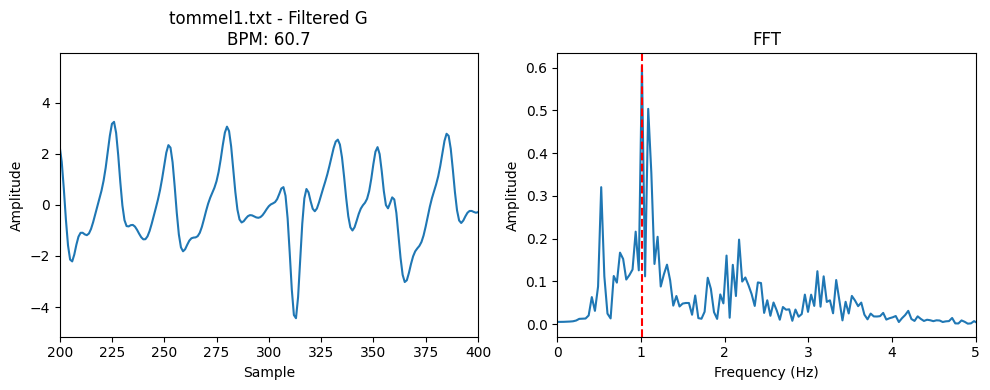

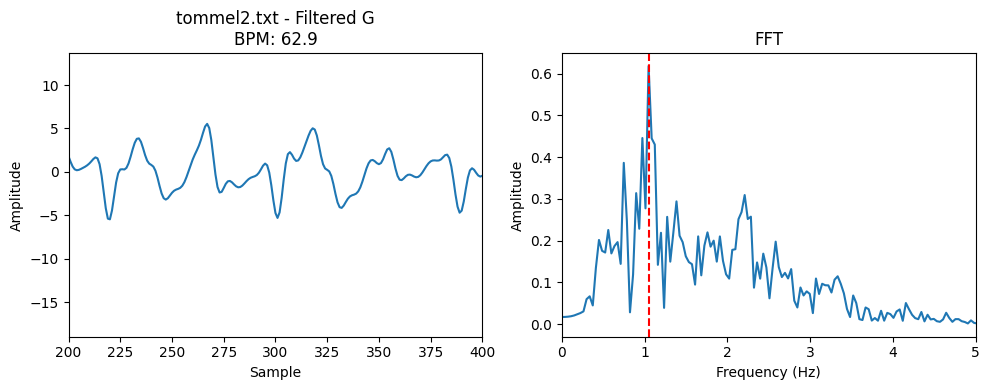

Mean BPM: 61.79775280898877
Std BPM: 1.1235955056179776


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

fs = 30
lowcut = 0.5
highcut = 4

files = ["tommel1.txt",
         "tommel2.txt",]

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
bpms = []


for filename in files:

    data = np.loadtxt(filename)
    G = data[:,1]

    G_ac = G - np.mean(G)
    G_ac = G_ac[3*fs:]
    G_filt = filtfilt(b, a, G_ac)

    N = len(G_filt)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(G_filt)) / N

    mask = (freqs >= 0.5) & (freqs <= 4)
    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    peak_freq = freqs_band[np.argmax(fft_band)]
    bpm = peak_freq * 60
    bpms.append(bpm)


    plt.figure(figsize=(10,4))


    plt.subplot(1,2,1)
    plt.plot(G_filt)
    plt.title(f"{filename} - Filtered G\nBPM: {bpm:.1f}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.xlim(200,400)

    
    plt.subplot(1,2,2)
    plt.plot(freqs, fft_vals)
    plt.xlim(0,5)
    plt.axvline(peak_freq, color='r', linestyle='--')
    plt.title("FFT")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

print("Mean BPM:", np.mean(bpms))
print("Std BPM:", np.std(bpms))


In [3]:
def compute_snr(signal, fs):

    N = len(signal)

    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N

    
    mask = (freqs >= 0.5) & (freqs <= 4)

    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    
    peak_idx = np.argmax(fft_band)
    peak_freq = freqs_band[peak_idx]
    peak_amp = fft_band[peak_idx]

    
    exclude = 0.1
    noise_mask = np.abs(freqs_band - peak_freq) > exclude
    noise_vals = fft_band[noise_mask]

    noise_mean = np.mean(noise_vals)

    snr_linear = peak_amp / noise_mean
    snr_db = 20 * np.log10(snr_linear)

    bpm = peak_freq * 60

    return bpm, snr_linear, snr_db

bpm_G, snr_G, snr_G_db = compute_snr(G_filt, fs)


print("G: BPM =", f"{bpm_G:.1f}", "SNR =", f"{snr_G_db:.1f}", "dB")


G: BPM = 62.9 SNR = 13.4 dB
